In [2]:
## need to consider at what temperature carbon veiling becomes a problem

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle as pkl
import os, sys
import gzip

sys.path.append("../interface/")
#import synthetic_functions
import matplotlib
plt.rcParams['font.family'] = "Times New Roman"
from scipy.ndimage import gaussian_filter
%matplotlib notebook

Need to remake the Carbon_veiling_corrected.pdf plot, using the new interpolators

## Initialize

In [3]:
### We want the unnormalized version 
path = 'libraries/'
spec_interp = pkl.load(gzip.open(path + 'LinearNDInterp.pkl.gz', 'rb'))

#grav_interp = synthetic_functions.get_grav_interp(mode='format')


In [4]:
group_dict = {
            "GI":   {'FEH': -2.5, "CARBON": 7.9, 'CFE' : 1.97},
            "GII":  {'FEH': -3.5, "CARBON": 5.9, 'CFE' : 0.97},
            'GIII': {'FEH': -4.3, "CARBON": 7.0, 'CFE' : 2.87}
             }

In [5]:
### Numb
dim = 5
tmin, tmax = 4000, 5000 

t_array = np.linspace(tmin, tmax, dim)
print(t_array)

DWARF = {"TEFF" : t_array, 'GI' : {}, 'GII' : {}, 'GIII' : {}}
GIANT = {"TEFF" : t_array, "GI" : {}, 'GII' : {}, 'GIII' : {}}




[4000. 4250. 4500. 4750. 5000.]


In [6]:
### load gravity

# I don't know why we have two versions of gravity interpolator
grav_interp = pkl.load(open('libraries/grav_interp.pkl', 'rb'))
print(grav_interp['GIANT'])
grav_interp_raw = pkl.load(open('libraries/grav_interp.pkl', 'rb'))
grav_interp_raw['GIANT']

#pd.read_pickle('libraries/grav_interp.pkl')
grav_interp


{'GIANT': <scipy.interpolate.interpnd.LinearNDInterpolator at 0x7fbc882f67f0>,
 'DWARF': <scipy.interpolate.interpnd.LinearNDInterpolator at 0x7fbc484239d0>}

In [7]:
# testing what log g values are interpolated from Teff and [Fe/H]
for group in ['GI', 'GII', 'GIII']:
    DWARF[group]['LOGG'] = grav_interp['DWARF'](np.r_[[t_array, np.ones(dim) * group_dict[group]['FEH']]].T)
    print(DWARF[group]['LOGG'])
    GIANT[group]['LOGG'] = grav_interp['GIANT'](np.r_[[t_array, np.ones(dim) * group_dict[group]['FEH']]].T)
    print(GIANT[group]['LOGG'])



[4.90211525 4.8873396  4.87056443 4.85119267 4.82323145]
[0.         0.21356806 0.82071542 1.40863936 2.04335655]
[4.99042521 4.95730066 4.92477296 4.8914518  4.85455868]
[0.         0.0272636  0.6134446  1.31539407 1.99325573]
[4.99808504 4.99013515 4.98495459 4.92408062 4.84658491]
[0.         0.16884592 0.7287625  1.29427475 1.86293442]


In [8]:
### GROUP I
group = 'GIII'
frame_list = []
for i in range(dim):
    
    print([t_array[i], DWARF[group]['LOGG'][i], group_dict[group]['FEH'], group_dict[group]['CFE']])
    flux = spec_interp([t_array[i], DWARF[group]['LOGG'][i], group_dict[group]['FEH'], group_dict[group]['CFE']])
    
    #print(flux)
    
    frame_list.append(pd.DataFrame({'wave' : np.arange(3000, 5001, 1), 
                          'flux' : flux.flatten()}))
    
DWARF[group]['frames'] = frame_list

frame_list = []
    
for i in range(dim):
    
    flux = spec_interp([t_array[i], GIANT[group]['LOGG'][i], group_dict[group]['FEH'], group_dict[group]['CFE']])
    
    frame_list.append(pd.DataFrame({'wave' : np.arange(3000, 5001, 1), 
                          'flux' : flux.flatten()}))
    
    
GIANT[group]['frames'] = frame_list
    


[4000.0, 4.998085041556232, -4.3, 2.87]


AttributeError: 'Delaunay' object has no attribute '_points'

## PLOT

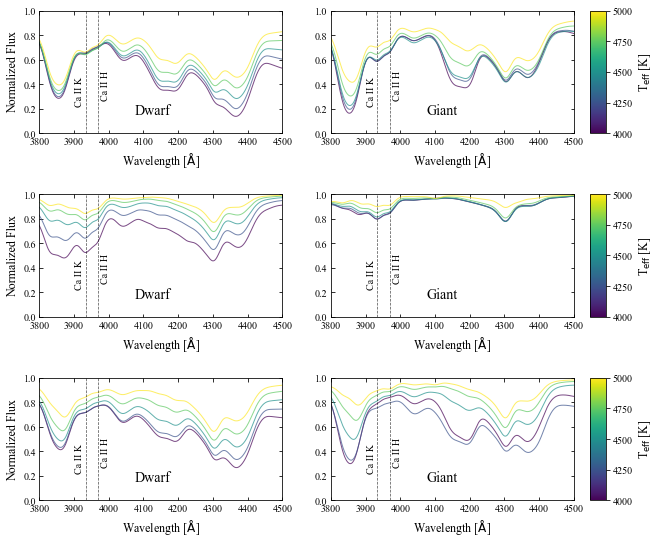

In [22]:
fig, ax = plt.subplots(3,2, figsize=(11,8.5))

#ax[0,0].set_title("Dwarf", fontsize=14)
#ax[0,1].set_title("Giant", fontsize=14)
color_map = plt.cm.viridis #jet
color_array = color_map(np.linspace(0,1,dim))

sigma_one=15
sigma_two = 1


wavelength = np.arange(3000, 5001, 1)

fig.subplots_adjust(hspace=0.5)
#Group I

alphaset=0.30
alphabold=0.7
linewidth=0.75
linebold = 1.0
boldstyle='-'
### DWARFS LEFT


##GI
#[ax[0,0].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_two), 
#              color=color_array[i], alpha=alphaset, linewidth=linewidth) for i,spec in enumerate(DWARF['GI']['frames'])]

#[ax[0,1].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_two), 
#              color=color_array[i], alpha=alphaset, linewidth=linewidth) for i,spec in enumerate(GIANT['GI']['frames'])]



##GI
#[ax[1,0].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_two), 
#              color=color_array[i], alpha=alphaset, linewidth=linewidth) for i,spec in enumerate(DWARF['GII']['frames'])]

#[ax[1,1].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_two), 
#              color=color_array[i], alpha=alphaset, linewidth=linewidth) for i,spec in enumerate(GIANT['GII']['frames'])]


##GI
#[ax[2,0].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_two), 
#              color=color_array[i], alpha=alphaset, linewidth=linewidth) for i,spec in enumerate(DWARF['GIII']['frames'])]

#[ax[2,1].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_two), 
#              color=color_array[i], alpha=alphaset, linewidth=linewidth) for i,spec in enumerate(GIANT['GIII']['frames'])]



################################################################################################



[ax[0,0].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_one), 
              color=color_array[i], alpha=alphabold, linewidth=linebold, linestyle=boldstyle) for i,spec in enumerate(DWARF['GI']['frames'])]

[ax[0,1].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_one), 
              color=color_array[i], alpha=alphabold, linewidth=linebold, linestyle=boldstyle) for i,spec in enumerate(GIANT['GI']['frames'])]



##GI
[ax[1,0].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_one), 
              color=color_array[i], alpha=alphabold, linewidth=linebold, linestyle=boldstyle) for i,spec in enumerate(DWARF['GII']['frames'])]

[ax[1,1].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_one), 
              color=color_array[i], alpha=alphabold, linewidth=linebold, linestyle=boldstyle) for i,spec in enumerate(GIANT['GII']['frames'])]


##GI
[ax[2,0].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_one), 
              color=color_array[i], alpha=alphabold, linewidth=linebold, linestyle=boldstyle) for i,spec in enumerate(DWARF['GIII']['frames'])]

[ax[2,1].plot(spec['wave'], gaussian_filter(spec['flux'], sigma=sigma_one), 
              color=color_array[i], alpha=alphabold, linewidth=linebold, linestyle=boldstyle) for i,spec in enumerate(GIANT['GIII']['frames'])]




### GIANTS RIGHT






props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

ax[0,0].text(4075, 0.15,"Dwarf", fontsize=14)
ax[1,0].text(4075, 0.15,"Dwarf", fontsize=14)
ax[2,0].text(4075, 0.15,"Dwarf", fontsize=14)

ax[0,1].text(4075, 0.15,"Giant", fontsize=14)
ax[1,1].text(4075, 0.15,"Giant", fontsize=14)
ax[2,1].text(4075, 0.15,"Giant", fontsize=14)

plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)

yspan = 0.2
rightx = 0.82
cax = [plt.axes([rightx, 0.1, 0.02, yspan]), plt.axes([rightx, 0.4, 0.02, yspan]), plt.axes([rightx, 0.7, 0.02, yspan])]
norm = matplotlib.colors.Normalize(vmin=4000, vmax=5000)
#plt.colorbar(cax=cax)

cb1 = [matplotlib.colorbar.ColorbarBase(label, cmap=color_map,
                                norm=norm,
                                orientation='vertical') for label in cax]

#[label.set_ticks(np.arange(4000, 5750, 250)) for label in cb1]
[label.set_ticks(np.arange(4000, 5250, 250)) for label in cb1]


[label.set_label(r"T$_{\rm eff}$ [K]", fontsize=12) for label in cb1]

[label.axvline(3969, linestyle="--", color="black", alpha=0.65, linewidth=0.75) for label in ax[:,0]]
[label.axvline(3969, linestyle="--", color="black", alpha=0.65, linewidth=0.75) for label in ax[:,1]]

[label.axvline(3934, linestyle="--", color="black", alpha=0.65, linewidth=0.75) for label in ax[:,0]]
[label.axvline(3934, linestyle="--", color="black", alpha=0.65, linewidth=0.75) for label in ax[:,1]]

[label.text(3900, 0.40, 'Ca II K', rotation=90.) for label in ax[:,0]]
[label.text(3975, 0.45, 'Ca II H', rotation=90.) for label in ax[:,0]]

[label.text(3900, 0.40, 'Ca II K', rotation=90.) for label in ax[:,1]]
[label.text(3975, 0.45, 'Ca II H', rotation=90.) for label in ax[:,1]]

[label.tick_params(direction="in", top=True, right=True) for label in ax[:,0]]
[label.tick_params(direction="in", top=True, right=True) for label in ax[:,1]]


[label.set_ylim([0.0, 1.]) for label in ax[0,:]]
[label.set_ylim([0.0, 1.]) for label in ax[1,:]]
[label.set_ylim([0.0, 1.]) for label in ax[2,:]]
#[label.set_ylim([0.1, 1.]) for label in ax[:,1]]




[label.set_xlim([3800, 4500]) for label in ax[:,0]]
[label.set_xlim([3800, 4500]) for label in ax[:,1]]
[label.set_xlabel(r"Wavelength [$\rm \AA$]", fontsize=12) for label in ax[:,0]]
[label.set_xlabel(r"Wavelength [$\rm \AA$]", fontsize=12) for label in ax[:,1]]
[label.set_ylabel("Normalized Flux", fontsize=12) for label in ax[:,0]]

plt.savefig("plots/carbon_veiling_new.pdf", format="pdf")
plt.show()


In [144]:
np.arange(4000, 5750, 250)

array([4000, 4250, 4500, 4750, 5000, 5250, 5500])

Here's the breakdown of temperatures and $\log{g}$


|T$_{\rm eff}$ | 4000  | 4250 | 4500 | 4750 | 5000 | 5250 | 5500 |
|:-------     :|-------|------|------|------|------|------|------|
| Dwarf log(g) |   5   | 4.97 | 4.93 | 4.90 | 4.84 | 4.79 | 4.73 |
| Giant log(g) | -0.75 | 0    | 0.61 | 1.29 | 1.98 | 2.65 | 3.33 |




|           | A(C)  | [Fe/H] | [C/Fe] |
|:-------:|-------|------|------|
| Group I   |  7.96 |  -2.5  |   2    |
| Group II  |  6    |  -3.5  |  1.07  |
| Group III |  6.8  |  -4.5    |  2.87  |




In [7]:
### Group I

giant_out = open("GI_giant.dat", "w+")
dwarf_out = open("GI_dwarf.dat", "w+")

for t, dwarf_g, giant_g in zip(t_range, d_range, g_range):
    giant_out.write("%.2f" % t + "," + "%.2f" % giant_g + ",-2.5,2.0\n") 
    dwarf_out.write("%.2f" % t + "," + "%.2f" % dwarf_g + ",-2.5,2.0\n")
    

giant_out.close()
dwarf_out.close()

### Group II
giant_out = open("G2_giant.dat", "w+")
dwarf_out = open("G2_dwarf.dat", "w+")

for t, dwarf_g, giant_g in zip(t_range, d_range, g_range):
    giant_out.write("%.2f" % t + "," + "%.2f" % giant_g + ",-3.5,1.07\n") 
    dwarf_out.write("%.2f" % t + "," + "%.2f" % dwarf_g + ",-3.5,1.07\n")


### Group III
giant_out = open("G3_giant.dat", "w+")
dwarf_out = open("G3_dwarf.dat", "w+")

for t, dwarf_g, giant_g in zip(t_range, d_range, g_range):
    giant_out.write("%.2f" % t + "," + "%.2f" % giant_g + ",-4.5,2.87\n") 
    dwarf_out.write("%.2f" % t + "," + "%.2f" % dwarf_g + ",-4.5,2.87\n")

giant_out.close()
dwarf_out.close()  

### GROUP I

In [8]:
dwarf_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/dwarf/GI/"
dwarf_array = [pd.read_csv(dwarf_path + item, header=None, sep="\s+") for item in os.listdir(dwarf_path)]

print(os.listdir(dwarf_path))

giant_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/giant/GI/"
giant_array = [pd.read_csv(giant_path + item, header=None, sep="\s+") for item in os.listdir(giant_path)]


['T4526.3158g4.9290316z-2.5000000c2.0000000.csv', 'T4421.0526g4.9447053z-2.5000000c2.0000000.csv', 'T4052.6316g4.9995632z-2.5000000c2.0000000.csv', 'T4736.8421g4.8976842z-2.5000000c2.0000000.csv', 'T4631.5789g4.9133579z-2.5000000c2.0000000.csv', 'T4473.6842g4.9368684z-2.5000000c2.0000000.csv', 'T4842.1053g4.8820105z-2.5000000c2.0000000.csv', 'T4894.7368g4.8741737z-2.5000000c2.0000000.csv', 'T4105.2632g4.9917263z-2.5000000c2.0000000.csv', 'T4263.1579g4.9682158z-2.5000000c2.0000000.csv', 'T4578.9474g4.9211947z-2.5000000c2.0000000.csv', 'T4210.5263g4.9760526z-2.5000000c2.0000000.csv', 'T4000.0000g5.0074000z-2.5000000c2.0000000.csv', 'T4684.2105g4.9055211z-2.5000000c2.0000000.csv', 'T4315.7895g4.9603789z-2.5000000c2.0000000.csv', 'T4947.3684g4.8663368z-2.5000000c2.0000000.csv', 'T4789.4737g4.8898474z-2.5000000c2.0000000.csv', 'T4157.8947g4.9838895z-2.5000000c2.0000000.csv', 'T4368.4211g4.9525421z-2.5000000c2.0000000.csv', 'T5000.0000g4.8400000z-2.5000000c2.0000000.csv']


KeyError: 1

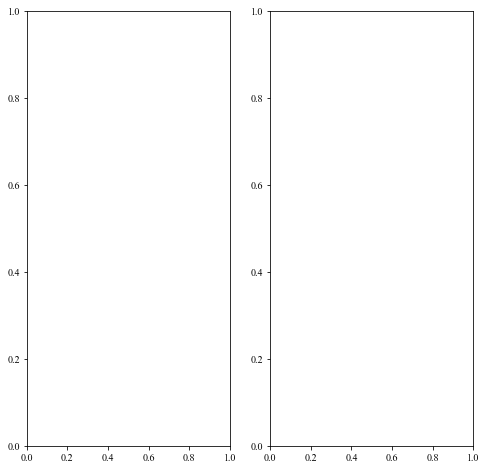

In [11]:
fig,ax = plt.subplots(1,2, figsize=(8,8))
[ax[0].plot(spec[0], spec[1] + i, linewidth=0.75, color="black") for i, spec in enumerate(dwarf_array)]
[ax[1].plot(spec[0], spec[1] + i, linewidth=0.75, color="black") for i, spec in enumerate(giant_array)]

#### dwarf
[ax[0].text(4000, i+1.03, "Teff:  "+name.split("T")[1].split("g")[0] + "K") for i, name in enumerate(os.listdir(dwarf_path))]
#### giant
[ax[1].text(4000, i+1.03, "Teff:  "+name.split("T")[1].split("g")[0] + "K") for i, name in enumerate(os.listdir(giant_path))]

fig.suptitle("Group I\n A(C) = 8.0, [Fe/H]=-2.5, [C/Fe]=2.0", fontsize=15)
ax[0].set_title("Dwarf", fontsize=14)
ax[1].set_title("Giant", fontsize=14)

[label.set_xlabel(r"Wavelength [$\AA$]", fontsize=14) for label in ax]
[[label.axhline(i+1, linestyle="--") for label in ax] for i in range(len(giant_array))]

[label.set_xlim([3800, 4500]) for label in ax]

#plt.savefig("plots/GI_veiling.pdf", format="pdf")

In [12]:
print(os.listdir(dwarf_path))
print(os.listdir(giant_path))

['T4526.3158g4.9290316z-2.5000000c2.0000000.csv', 'T4421.0526g4.9447053z-2.5000000c2.0000000.csv', 'T4052.6316g4.9995632z-2.5000000c2.0000000.csv', 'T4736.8421g4.8976842z-2.5000000c2.0000000.csv', 'T4631.5789g4.9133579z-2.5000000c2.0000000.csv', 'T4473.6842g4.9368684z-2.5000000c2.0000000.csv', 'T4842.1053g4.8820105z-2.5000000c2.0000000.csv', 'T4894.7368g4.8741737z-2.5000000c2.0000000.csv', 'T4105.2632g4.9917263z-2.5000000c2.0000000.csv', 'T4263.1579g4.9682158z-2.5000000c2.0000000.csv', 'T4578.9474g4.9211947z-2.5000000c2.0000000.csv', 'T4210.5263g4.9760526z-2.5000000c2.0000000.csv', 'T4000.0000g5.0074000z-2.5000000c2.0000000.csv', 'T4684.2105g4.9055211z-2.5000000c2.0000000.csv', 'T4315.7895g4.9603789z-2.5000000c2.0000000.csv', 'T4947.3684g4.8663368z-2.5000000c2.0000000.csv', 'T4789.4737g4.8898474z-2.5000000c2.0000000.csv', 'T4157.8947g4.9838895z-2.5000000c2.0000000.csv', 'T4368.4211g4.9525421z-2.5000000c2.0000000.csv', 'T5000.0000g4.8400000z-2.5000000c2.0000000.csv']
['T4750g1.50z-2.50c

#### Group II

In [13]:
dwarf_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/dwarf/GII/"
dwarf_array = [pd.read_csv(dwarf_path + item, header=None, sep="\s+") for item in os.listdir(dwarf_path)]

print(os.listdir(dwarf_path))

giant_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/giant/GII/"
giant_array = [pd.read_csv(giant_path + item, header=None, sep="\s+") for item in os.listdir(giant_path)]


['T4789.4737g4.8898474z-3.5000000c1.0000000.csv', 'T4157.8947g4.9838895z-3.5000000c1.0000000.csv', 'T5000.0000g4.8400000z-3.5000000c1.0000000.csv', 'T4368.4211g4.9525421z-3.5000000c1.0000000.csv', 'T4684.2105g4.9055211z-3.5000000c1.0000000.csv', 'T4000.0000g5.0074000z-3.5000000c1.0000000.csv', 'T4315.7895g4.9603789z-3.5000000c1.0000000.csv', 'T4947.3684g4.8663368z-3.5000000c1.0000000.csv', 'T4263.1579g4.9682158z-3.5000000c1.0000000.csv', 'T4578.9474g4.9211947z-3.5000000c1.0000000.csv', 'T4894.7368g4.8741737z-3.5000000c1.0000000.csv', 'T4105.2632g4.9917263z-3.5000000c1.0000000.csv', 'T4210.5263g4.9760526z-3.5000000c1.0000000.csv', 'T4473.6842g4.9368684z-3.5000000c1.0000000.csv', 'T4842.1053g4.8820105z-3.5000000c1.0000000.csv', 'T4736.8421g4.8976842z-3.5000000c1.0000000.csv', 'T4052.6316g4.9995632z-3.5000000c1.0000000.csv', 'T4631.5789g4.9133579z-3.5000000c1.0000000.csv', 'T4526.3158g4.9290316z-3.5000000c1.0000000.csv', 'T4421.0526g4.9447053z-3.5000000c1.0000000.csv']


KeyError: 1

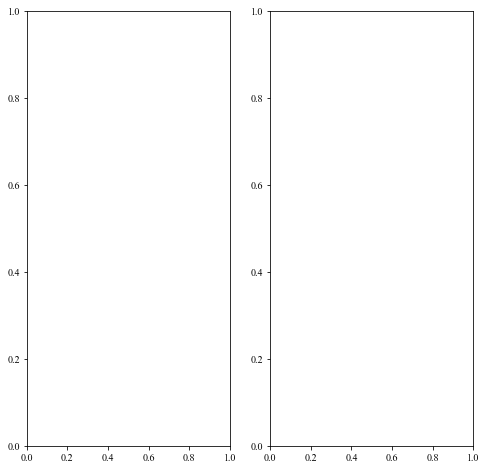

In [14]:
fig,ax = plt.subplots(1,2, figsize=(8,8))
[ax[0].plot(spec[0], spec[1] + i, linewidth=0.75, color="black") for i, spec in enumerate(dwarf_array)]
[ax[1].plot(spec[0], spec[1] + i, linewidth=0.75, color="black") for i, spec in enumerate(giant_array)]

#### dwarf
[ax[0].text(4000, i+1.03, "Teff:  "+name.split("T")[1].split("g")[0] + "K") for i, name in enumerate(os.listdir(dwarf_path))]
#### giant
[ax[1].text(4000, i+1.03, "Teff:  "+name.split("T")[1].split("g")[0] + "K") for i, name in enumerate(os.listdir(giant_path))]

fig.suptitle("Group II\n A(C) = 6.0, [Fe/H]=-3.5, [C/Fe]=+1.0", fontsize=15)
ax[0].set_title("Dwarf", fontsize=14)
ax[1].set_title("Giant", fontsize=14)

[label.set_xlabel(r"Wavelength [$\AA$]", fontsize=14) for label in ax]
[[label.axhline(i+1, linestyle="--") for label in ax] for i in range(len(giant_array))]

[label.set_xlim([3800, 4500]) for label in ax]
#plt.savefig("plots/GII_veiling.pdf", format="pdf")

### Group III

In [15]:
dwarf_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/dwarf/GIII/"
dwarf_array = [pd.read_csv(dwarf_path + item, header=None, sep="\s+") for item in os.listdir(dwarf_path)]

print(os.listdir(dwarf_path))

giant_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/giant/GIII/"
giant_array = [pd.read_csv(giant_path + item, header=None, sep="\s+") for item in os.listdir(giant_path)]


['T4500g5.00z-4.50c+2.75.dat', 'T5250g5.00z-4.50c+2.75.dat', 'T4000g5.00z-4.50c+2.75.dat', 'T5500g5.00z-4.50c+2.75.dat', 'T4750g5.00z-4.50c+2.75.dat', 'T5000g5.00z-4.50c+2.75.dat', 'T4250g5.00z-4.50c+2.75.dat']


[(3800, 4500), (3800, 4500)]

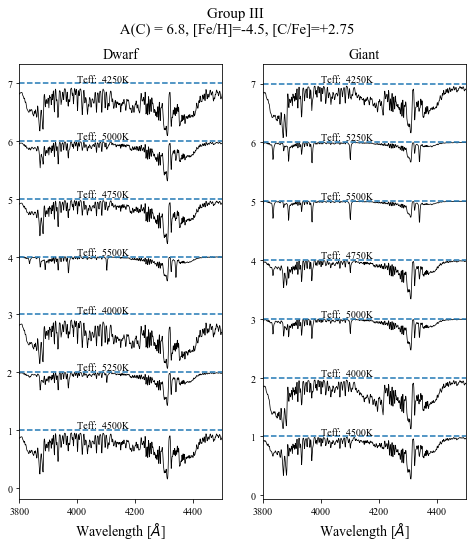

In [16]:
fig,ax = plt.subplots(1,2, figsize=(8,8))
[ax[0].plot(spec[0], spec[1] + i, linewidth=0.75, color="black") for i, spec in enumerate(dwarf_array)]
[ax[1].plot(spec[0], spec[1] + i, linewidth=0.75, color="black") for i, spec in enumerate(giant_array)]

#### dwarf
[ax[0].text(4000, i+1.03, "Teff:  "+name.split("T")[1].split("g")[0] + "K") for i, name in enumerate(os.listdir(dwarf_path))]
#### giant
[ax[1].text(4000, i+1.03, "Teff:  "+name.split("T")[1].split("g")[0] + "K") for i, name in enumerate(os.listdir(giant_path))]

fig.suptitle("Group III\n A(C) = 6.8, [Fe/H]=-4.5, [C/Fe]=+2.75", fontsize=15)
ax[0].set_title("Dwarf", fontsize=14)
ax[1].set_title("Giant", fontsize=14)

[label.set_xlabel(r"Wavelength [$\AA$]", fontsize=14) for label in ax]
[[label.axhline(i+1, linestyle="--") for label in ax] for i in range(len(giant_array))]

[label.set_xlim([3800, 4500]) for label in ax]
#plt.savefig("plots/GIII_veiling.pdf", format="pdf")

#### Combine and Smooth

IndexError: index 7 is out of bounds for axis 0 with size 7

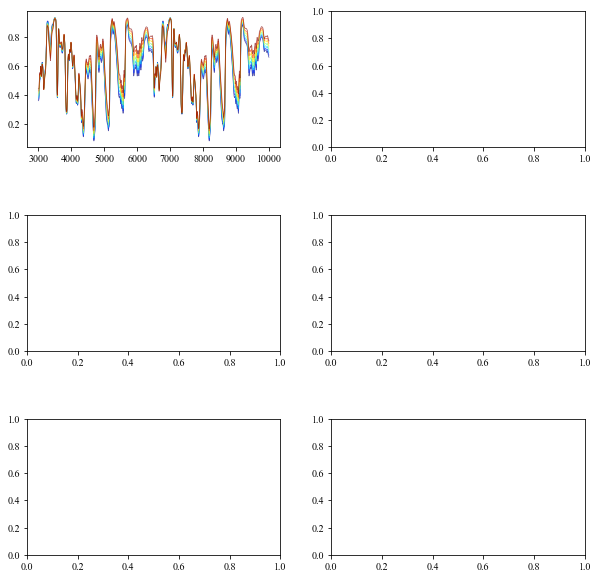

In [30]:
fig, ax = plt.subplots(3,2, figsize=(10,10))

#ax[0,0].set_title("Dwarf", fontsize=14)
#ax[0,1].set_title("Giant", fontsize=14)
color_array = plt.cm.jet(np.linspace(0,1,7))
sigmaset=10

fig.subplots_adjust(hspace=0.5)
#Group I
dwarf_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/dwarf/GI/"
dwarf_array = [pd.read_csv(dwarf_path + item) for item in os.listdir(dwarf_path)]
dwarf_order = np.argsort([float(name.split('T')[1].split('g')[0]) for name in os.listdir(dwarf_path)])

giant_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/giant/GI/"
giant_array = [pd.read_csv(giant_path + item, header=None, sep="\s+") for item in os.listdir(giant_path)]
giant_order = np.argsort([float(name.split('T')[1].split('g')[0]) for name in os.listdir(giant_path)])
#ax[0,0].text

[ax[0,0].plot(dwarf_array[index]['wl'], gaussian_filter(dwarf_array[index]['flux'], sigma=sigmaset), linewidth=0.75, color=color_array[i], alpha=0.65) for i, index in enumerate(dwarf_order)]
#[ax[0,1].plot(giant_array[index][0], gaussian_filter(giant_array[index][1], sigma=sigmaset), linewidth=0.75, color=color_array[i], alpha=0.65) for i, index in enumerate(giant_order)]


#Group II
dwarf_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/dwarf/GII/"
dwarf_array = [pd.read_csv(dwarf_path + item, header=None, sep="\s+") for item in os.listdir(dwarf_path)]
dwarf_order = np.argsort([float(name.split('T')[1].split('g')[0]) for name in os.listdir(dwarf_path)])

giant_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/giant/GII/"
giant_array = [pd.read_csv(giant_path + item, header=None, sep="\s+") for item in os.listdir(giant_path)]
giant_order = np.argsort([float(name.split('T')[1].split('g')[0]) for name in os.listdir(giant_path)])

#[ax[1,0].plot(dwarf_array[index][0], gaussian_filter(dwarf_array[index][1], sigma=sigmaset), linewidth=0.75, color=color_array[i], alpha=0.65) for i, index in enumerate(dwarf_order)]
#[ax[1,1].plot(giant_array[index][0], gaussian_filter(giant_array[index][1], sigma=sigmaset), linewidth=0.75, color=color_array[i], alpha=0.65) for i, index in enumerate(giant_order)]




#Group III
dwarf_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/dwarf/GIII/"
dwarf_array = [pd.read_csv(dwarf_path + item, header=None, sep="\s+") for item in os.listdir(dwarf_path)]
dwarf_order = np.argsort([float(name.split('T')[1].split('g')[0]) for name in os.listdir(dwarf_path)])


giant_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/giant/GIII/"
giant_array = [pd.read_csv(giant_path + item, header=None, sep="\s+") for item in os.listdir(giant_path)]
giant_order = np.argsort([float(name.split('T')[1].split('g')[0]) for name in os.listdir(giant_path)])




#[ax[2,0].plot(dwarf_array[index][0], gaussian_filter(dwarf_array[index][1], sigma=sigmaset), linewidth=0.75, color=color_array[i], alpha=0.65) for i, index in enumerate(dwarf_order)]
#[ax[2,1].plot(giant_array[index][0], gaussian_filter(giant_array[index][1], sigma=sigmaset), linewidth=0.75, color=color_array[i], alpha=0.65) for i, index in enumerate(giant_order)]


props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)

ax[0,0].text(4075, 0.15,"Dwarf", fontsize=14)
ax[1,0].text(4075, 0.36,"Dwarf", fontsize=14)
ax[2,0].text(4075, 0.32,"Dwarf", fontsize=14)

ax[0,1].text(4075, 0.15,"Giant", fontsize=14)
ax[1,1].text(4075, 0.36,"Giant", fontsize=14)
ax[2,1].text(4075, 0.32,"Giant", fontsize=14)

plt.subplots_adjust(bottom=0.1, right=0.8, top=0.9)


cax = plt.axes([0.83, 0.1, 0.025, 0.8])
norm = matplotlib.colors.Normalize(vmin=4000, vmax=5500)
#plt.colorbar(cax=cax)

cb1 = matplotlib.colorbar.ColorbarBase(cax, cmap=plt.cm.jet,
                                norm=norm,
                                orientation='vertical')
cb1.set_label(r"T$_{\rm eff}$ [K]", fontsize=14)

[label.axvline(3969, linestyle="--", color="black", alpha=0.65, linewidth=0.75) for label in ax[:,0]]
[label.axvline(3969, linestyle="--", color="black", alpha=0.65, linewidth=0.75) for label in ax[:,1]]

[label.axvline(3934, linestyle="--", color="black", alpha=0.65, linewidth=0.75) for label in ax[:,0]]
[label.axvline(3934, linestyle="--", color="black", alpha=0.65, linewidth=0.75) for label in ax[:,1]]
[label.text(3900, 0.40, 'Ca II K', rotation=90.) for label in ax[0,:]]
[label.text(3975, 0.45, 'Ca II H', rotation=90.) for label in ax[0,:]]

[label.tick_params(direction="in", top=True, right=True) for label in ax[:,0]]
[label.tick_params(direction="in", top=True, right=True) for label in ax[:,1]]


[label.set_ylim([0.1, 1.]) for label in ax[0,:]]
[label.set_ylim([0.3, 1.]) for label in ax[1,:]]
[label.set_ylim([0.25, 1.]) for label in ax[2,:]]
#[label.set_ylim([0.1, 1.]) for label in ax[:,1]]




[label.set_xlim([3800, 4500]) for label in ax[:,0]]
[label.set_xlim([3800, 4500]) for label in ax[:,1]]
[label.set_xlabel(r"Wavelength [$\rm \AA$]", fontsize=14) for label in ax[:,0]]
[label.set_xlabel(r"Wavelength [$\rm \AA$]", fontsize=14) for label in ax[:,1]]
[label.set_ylabel("Normalized Flux [%]", fontsize=14) for label in ax[:,0]]

#plt.savefig("plots/carbon_veiling_smoothed_test.pdf", format="pdf")
plt.show()


In [35]:
len(color_array)

7

In [27]:
ac.ac(2.0, -2.5)

7.93

In [122]:


#Group I
dwarf_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/dwarf/GI/"
GI_dwarf_array= [pd.read_csv(dwarf_path + item, header=None, sep="\s+") for item in os.listdir(dwarf_path)]

giant_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/giant/GI/"
GI_giant_array = [pd.read_csv(giant_path + item, header=None, sep="\s+") for item in os.listdir(giant_path)]


#Group II
dwarf_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/dwarf/GII/"
GII_dwarf_array = [pd.read_csv(dwarf_path + item, header=None, sep="\s+") for item in os.listdir(dwarf_path)]

giant_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/giant/GII/"
GII_giant_array = [pd.read_csv(giant_path + item, header=None, sep="\s+") for item in os.listdir(giant_path)]


#Group III
dwarf_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/dwarf/GIII/"
GIII_dwarf_array = [pd.read_csv(dwarf_path + item, header=None, sep="\s+") for item in os.listdir(dwarf_path)]

giant_path = "/Users/MasterD/Google Drive/Yoon_UMP/synthetic/giant/GIII/"
GIII_giant_array = [pd.read_csv(giant_path + item, header=None, sep="\s+") for item in os.listdir(giant_path)]



In [148]:
def MAD(input_vector):
    return np.median(np.abs(input_vector - np.median(input_vector)))

In [183]:
#for i in range(len(GI_dwarf_array)):
sigmaset=50

DI_DIFF = [np.median(gaussian_filter(GI_dwarf_array[i][GI_dwarf_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GI_dwarf_array[-1][GI_dwarf_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GI_dwarf_array))]
DI_SPREAD = [MAD(gaussian_filter(GI_dwarf_array[i][GI_dwarf_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GI_dwarf_array[-1][GI_dwarf_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GI_dwarf_array))]

GI_DIFF = [np.median(gaussian_filter(GI_giant_array[i][GI_giant_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GI_giant_array[-1][GI_giant_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GI_giant_array))]
GI_SPREAD = [MAD(gaussian_filter(GI_giant_array[i][GI_giant_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GI_giant_array[-1][GI_giant_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GI_giant_array))]

DII_DIFF = [np.median(gaussian_filter(GII_dwarf_array[i][GII_dwarf_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GII_dwarf_array[-1][GII_dwarf_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GII_dwarf_array))]
DII_SPREAD = [MAD(gaussian_filter(GII_dwarf_array[i][GII_dwarf_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GII_dwarf_array[-1][GII_dwarf_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GII_dwarf_array))]

GII_DIFF = [np.median(gaussian_filter(GII_giant_array[i][GII_giant_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GII_giant_array[-1][GII_giant_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GII_giant_array))]
GII_SPREAD = [MAD(gaussian_filter(GII_giant_array[i][GII_giant_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GII_giant_array[-1][GII_giant_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GII_giant_array))]


DIII_DIFF = [np.median(gaussian_filter(GIII_dwarf_array[i][GIII_dwarf_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GIII_dwarf_array[-1][GIII_dwarf_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GIII_dwarf_array))]
DIII_SPREAD = [MAD(gaussian_filter(GIII_dwarf_array[i][GIII_dwarf_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GIII_dwarf_array[-1][GIII_dwarf_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GIII_dwarf_array))]


GIII_DIFF = [np.median(gaussian_filter(GIII_giant_array[i][GIII_giant_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GIII_giant_array[-1][GIII_giant_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GIII_giant_array))]
GIII_SPREAD = [MAD(gaussian_filter(GIII_giant_array[i][GIII_giant_array[i][0].between(3800, 4500, inclusive=True)][1], sigma=sigmaset) - gaussian_filter(GIII_giant_array[-1][GIII_giant_array[-1][0].between(3800, 4500, inclusive=True)][1], sigma=10)) for i in range(len(GIII_giant_array))]

<IPython.core.display.Javascript object>


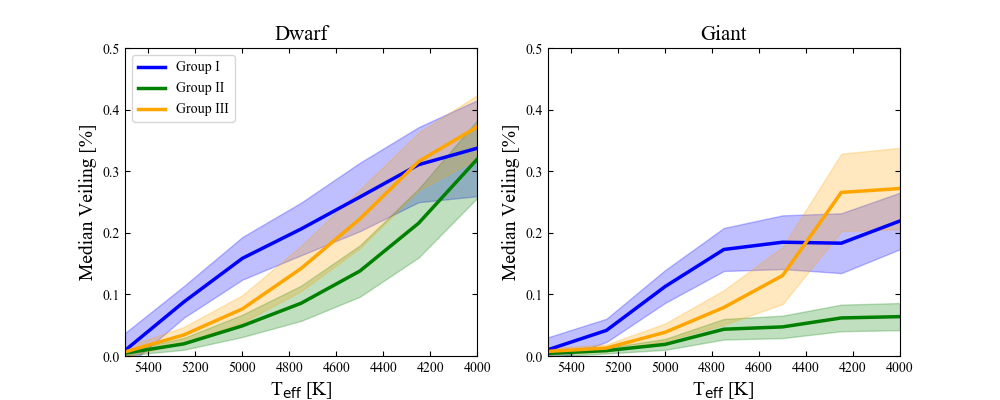

In [184]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
t_span = np.linspace(4000, 5500, 7)
ax[0].plot(np.linspace(4000, 5500, 7), -1*np.array(DI_DIFF), color="blue", linewidth=2.5, label="Group I")
ax[0].fill_between(t_span, -1*np.array(DI_DIFF) -DI_SPREAD, -1*np.array(DI_DIFF) +DI_SPREAD, color="blue", alpha=0.25)

ax[1].plot(np.linspace(4000, 5500, 7), -1*np.array(GI_DIFF), color="blue", linewidth=2.5)
ax[1].fill_between(t_span, -1*np.array(GI_DIFF) -GI_SPREAD, -1*np.array(GI_DIFF) +GI_SPREAD, color="blue", alpha=0.25)


ax[0].plot(np.linspace(4000, 5500, 7), -1*np.array(DII_DIFF), color="green", linewidth=2.5, label="Group II")
ax[0].fill_between(t_span, -1*np.array(DII_DIFF) -DII_SPREAD, -1*np.array(DII_DIFF) +DII_SPREAD, color="green", alpha=0.25)


ax[1].plot(np.linspace(4000, 5500, 7), -1*np.array(GII_DIFF), color="green", linewidth=2.5)
ax[1].fill_between(t_span, -1*np.array(GII_DIFF) -GII_SPREAD, -1*np.array(GII_DIFF) +GII_SPREAD, color="green", alpha=0.25)

ax[0].plot(np.linspace(4000, 5500, 7), -1*np.array(DIII_DIFF), color="orange", linewidth=2.5, label='Group III')
ax[0].fill_between(t_span, -1*np.array(DIII_DIFF) -DIII_SPREAD, -1*np.array(DIII_DIFF) +DIII_SPREAD, color="orange", alpha=0.25)

ax[1].plot(np.linspace(4000, 5500, 7), -1*np.array(GIII_DIFF), color="orange", linewidth=2.5)
ax[1].fill_between(t_span, -1*np.array(GIII_DIFF) -GIII_SPREAD, -1*np.array(GIII_DIFF) +GIII_SPREAD, color="orange", alpha=0.25)

ax[0].legend(loc=2)
[label.set_xlabel(r"T$_{\rm eff}$ [K]", fontsize=14) for label in ax]
[label.set_ylabel(r"Median Veiling [%]", fontsize=14) for label in ax]

[label.set_xlim([5500,4000]) for label in ax]
[label.set_ylim([0,0.5]) for label in ax]
[label.tick_params(direction="in", top=True, right=True) for label in ax]

ax[0].set_title("Dwarf", fontsize=15)
ax[1].set_title("Giant", fontsize=15)

plt.show()
#plt.savefig("plots/relative_deviation.pdf", format="pdf")